In [32]:
# ============================================================================
# PHASE 1: WTI & GASOLINE PRICE RELATIONSHIP ANALYSIS
# Goal: Test for cointegration between WTI Crude Oil and RBOB Gasoline prices
# ============================================================================
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import VECM
import warnings
warnings.filterwarnings('ignore')


print("=" * 70)
print("STEP 1: DOWNLOADING DATA")
print("=" * 70)

# Download WTI Crude Oil Futures (CL=F) and RBOB Gasoline Futures (RB=F)
wti_data = yf.download('CL=F', start='2020-01-01', end=datetime.today())
rbob_data = yf.download('RB=F', start='2020-01-01', end=datetime.today())

# Extract Close prices and flatten to Series
wti = wti_data['Close'].squeeze()
rbob = rbob_data['Close'].squeeze()

# Combine into single DataFrame and remove days where either series has missing data
df = pd.DataFrame({'WTI': wti, 'RBOB': rbob}).dropna()

# Standardize units: Convert RBOB from $/gallon to $/barrel (1 barrel = 42 gallons)
df['RBOB_per_bbl'] = df['RBOB'] * 42

# Optional: Calculate 3:2:1 Crack Spread (refining margin, not used in VECM)
# Formula: Revenue from 2 barrels of gasoline minus cost of 3 barrels of crude
df['Crack_Spread'] = (2 * df['RBOB_per_bbl']) - (3 * df['WTI'])

# Display summary statistics
print(f"\nData range: {df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Total observations: {len(df)}")
print(f"\nLatest prices ({df.index[-1].strftime('%Y-%m-%d')}):")
print(f"  WTI Crude Oil: ${df['WTI'].iloc[-1]:.2f}/bbl")
print(f"  RBOB Gasoline: ${df['RBOB'].iloc[-1]:.2f}/gal (${df['RBOB_per_bbl'].iloc[-1]:.2f}/bbl)")
print(f"  3:2:1 Crack Spread: ${df['Crack_Spread'].iloc[-1]:.2f}/bbl")

print("\n" + "=" * 70)
print("STEP 2: STATIONARITY TESTING (ADF TEST)")
print("=" * 70)

# ----------------------------------------------------------------------------
# STEP 2: AUGMENTED DICKEY-FULLER (ADF) TEST
# Goal: Confirm both series are I(1) - non-stationary in levels, stationary in first differences
# ----------------------------------------------------------------------------

def adf_test(series, series_name, test_type="levels"):
    """
    Perform ADF test and display results in readable format.
    
    Parameters:
    - series: pandas Series to test
    - series_name: name of the series for display
    - test_type: "levels" or "first differences"
    """
    result = adfuller(series.dropna(), autolag='AIC')
    
    print(f"\n{series_name} ({test_type}):")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Critical Values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.4f}")
    
    # Interpretation
    if result[1] < 0.05:
        print(f"  ✓ STATIONARY (reject H0: unit root exists, p < 0.05)")
    else:
        print(f"  ✗ NON-STATIONARY (fail to reject H0: unit root exists, p ≥ 0.05)")
    
    return result

# Test 1: Levels (should be NON-stationary for I(1) series)
print("\n--- TESTING LEVELS (Raw Prices) ---")
print("Expected: NON-stationary (p-value > 0.05)")

adf_wti_levels = adf_test(df['WTI'], "WTI Crude Oil", "levels")
adf_rbob_levels = adf_test(df['RBOB_per_bbl'], "RBOB Gasoline", "levels")

# Test 2: First Differences (should be STATIONARY for I(1) series)
print("\n--- TESTING FIRST DIFFERENCES (Price Changes) ---")
print("Expected: STATIONARY (p-value < 0.05)")

# Calculate first differences
df['WTI_diff'] = df['WTI'].diff()
df['RBOB_diff'] = df['RBOB_per_bbl'].diff()

adf_wti_diff = adf_test(df['WTI_diff'], "WTI Crude Oil", "first differences")
adf_rbob_diff = adf_test(df['RBOB_diff'], "RBOB Gasoline", "first differences")

# Summary of I(1) confirmation
print("\n" + "=" * 70)
print("I(1) CONFIRMATION SUMMARY")
print("=" * 70)

wti_is_I1 = (adf_wti_levels[1] >= 0.05) and (adf_wti_diff[1] < 0.05)
rbob_is_I1 = (adf_rbob_levels[1] >= 0.05) and (adf_rbob_diff[1] < 0.05)

print(f"\nWTI Crude Oil is I(1): {wti_is_I1}")
print(f"  - Non-stationary in levels: {adf_wti_levels[1] >= 0.05} (p = {adf_wti_levels[1]:.4f})")
print(f"  - Stationary in first differences: {adf_wti_diff[1] < 0.05} (p = {adf_wti_diff[1]:.4f})")

print(f"\nRBOB Gasoline is I(1): {rbob_is_I1}")
print(f"  - Non-stationary in levels: {adf_rbob_levels[1] >= 0.05} (p = {adf_rbob_levels[1]:.4f})")
print(f"  - Stationary in first differences: {adf_rbob_diff[1] < 0.05} (p = {adf_rbob_diff[1]:.4f})")

if wti_is_I1 and rbob_is_I1:
    print("\n✓ BOTH SERIES ARE I(1) → Proceed to cointegration testing")
else:
    print("\n⚠ WARNING: One or both series may not be I(1). Review results before proceeding.")

print("\n" + "=" * 70)

[*********************100%***********************]  1 of 1 completed

STEP 1: DOWNLOADING DATA



[*********************100%***********************]  1 of 1 completed


Data range: 2020-01-02 to 2026-04-28
Total observations: 1590

Latest prices (2026-04-28):
  WTI Crude Oil: $99.86/bbl
  RBOB Gasoline: $3.41/gal ($143.25/bbl)
  3:2:1 Crack Spread: $-13.08/bbl

STEP 2: STATIONARITY TESTING (ADF TEST)

--- TESTING LEVELS (Raw Prices) ---
Expected: NON-stationary (p-value > 0.05)

WTI Crude Oil (levels):
  ADF Statistic: -1.7552
  p-value: 0.4029
  Critical Values:
    1%: -3.4345
    5%: -2.8634
    10%: -2.5677
  ✗ NON-STATIONARY (fail to reject H0: unit root exists, p ≥ 0.05)

RBOB Gasoline (levels):
  ADF Statistic: -1.6514
  p-value: 0.4563
  Critical Values:
    1%: -3.4345
    5%: -2.8634
    10%: -2.5677
  ✗ NON-STATIONARY (fail to reject H0: unit root exists, p ≥ 0.05)

--- TESTING FIRST DIFFERENCES (Price Changes) ---
Expected: STATIONARY (p-value < 0.05)

WTI Crude Oil (first differences):
  ADF Statistic: -27.6391
  p-value: 0.0000
  Critical Values:
    1%: -3.4345
    5%: -2.8634
    10%: -2.5677
  ✓ STATIONARY (reject H0: unit root exist

In [34]:
# ============================================================================
# STEP 3: LAG SELECTION
# Goal: Determine optimal lag length (p) for the VECM model
# Method: Test multiple lag lengths and select the one that minimizes BIC
# ============================================================================
print("=" * 70)
print("STEP 3: LAG SELECTION")
print("=" * 70)

# ----------------------------------------------------------------------------
# Prepare data for VAR model (used to determine lag length)
# ----------------------------------------------------------------------------

# Select the two price series for cointegration analysis
# Note: We use the raw prices in $/bbl (both standardized to same unit)
price_data = df[['WTI', 'RBOB_per_bbl']].dropna()
price_data.index.freq = pd.infer_freq(price_data.index)  # Auto-detect frequency

print(f"\nData prepared for lag selection:")
print(f"  Variables: WTI ($/bbl) and RBOB Gasoline ($/bbl)")
print(f"  Observations: {len(price_data)}")
print(f"  Date range: {price_data.index[0].strftime('%Y-%m-%d')} to {price_data.index[-1].strftime('%Y-%m-%d')}")

# ----------------------------------------------------------------------------
# Test multiple lag lengths and compare information criteria
# ----------------------------------------------------------------------------

# Fit VAR model (Vector AutoRegression - the unrestricted version of VECM)
# The lag_order selection will test lags from 0 to maxlags
model = VAR(price_data)

# Test lags from 1 to 15 (adjust maxlags if you want to test more)
# For daily financial data, 5-15 lags is typical (1-3 weeks of trading days)
lag_order_results = model.select_order(maxlags=15)

print("\n--- LAG ORDER SELECTION RESULTS ---")
print("\nInformation Criteria Summary:")
print(lag_order_results.summary())

# Extract the optimal lag for each criterion
print("\n--- OPTIMAL LAG BY CRITERION ---")
print(f"AIC (Akaike Information Criterion):     {lag_order_results.aic} lags")
print(f"BIC (Bayesian Information Criterion):   {lag_order_results.bic} lags")
print(f"FPE (Final Prediction Error):           {lag_order_results.fpe} lags")
print(f"HQIC (Hannan-Quinn Information Crit.):  {lag_order_results.hqic} lags")

# ----------------------------------------------------------------------------
# Select optimal lag (BIC is preferred for cointegration analysis)
# ----------------------------------------------------------------------------

optimal_lag = lag_order_results.bic

print("\n" + "=" * 70)
print("RECOMMENDATION")
print("=" * 70)
print(f"\n✓ Optimal lag length: {optimal_lag} days")
print(f"\nRationale:")
print(f"  - BIC penalizes model complexity more heavily than AIC")
print(f"  - This helps avoid overfitting in cointegration models")
print(f"  - The model will use the past {optimal_lag} days to capture market dynamics")

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print(f"\nThis means:")
print(f"  • Today's prices are influenced by the past {optimal_lag} trading days")
print(f"  • The VECM will use {optimal_lag} lagged differences in its specification")
print(f"  • You'll use this value (k_ar_diff={optimal_lag}) in the Johansen test")

# ----------------------------------------------------------------------------
# Visual diagnostic (optional): Show how criteria change across lags
# ----------------------------------------------------------------------------

print("\n--- DETAILED INFORMATION CRITERIA TABLE ---")
print("\nLag | AIC       | BIC       | FPE       | HQIC")
print("-" * 55)

# Access the detailed results for each lag
for lag in range(1, min(16, len(lag_order_results.ics['aic']) + 1)):
    try:
        aic_val = lag_order_results.ics['aic'][lag]
        bic_val = lag_order_results.ics['bic'][lag]
        fpe_val = lag_order_results.ics['fpe'][lag]
        hqic_val = lag_order_results.ics['hqic'][lag]
        
        # Highlight the BIC-optimal lag
        marker = " ← BIC optimal" if lag == optimal_lag else ""
        print(f"{lag:3d} | {aic_val:9.2f} | {bic_val:9.2f} | {fpe_val:9.2e} | {hqic_val:9.2f}{marker}")
    except (KeyError, IndexError):
        break

print("\n" + "=" * 70)
print(f"NEXT STEP: Use lag={optimal_lag} in the Johansen cointegration test")
print("=" * 70)

# Store the optimal lag for use in Step 4
optimal_lag_for_johansen = optimal_lag

STEP 3: LAG SELECTION

Data prepared for lag selection:
  Variables: WTI ($/bbl) and RBOB Gasoline ($/bbl)
  Observations: 1590
  Date range: 2020-01-02 to 2026-04-28

--- LAG ORDER SELECTION RESULTS ---

Information Criteria Summary:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        9.920       9.927   2.033e+04       9.922
1        3.506       3.526       33.32       3.514
2        3.411      3.445*       30.29       3.424
3        3.398       3.446       29.90      3.416*
4        3.394       3.455       29.79       3.417
5       3.394*       3.469      29.78*       3.422
6        3.397       3.486       29.88       3.430
7        3.398       3.500       29.90       3.436
8        3.401       3.516       29.98       3.444
9        3.403       3.532       30.04       3.451
10       3.407       3.550       30.16       3.460
11       3.407       3.563       30.16       3.465


In [36]:
# ============================================================================
# STEP 4: COINTEGRATION TESTING (JOHANSEN TEST)
# Goal: Prove that WTI and RBOB are cointegrated (r=1)
# Method: Johansen procedure with optimal lag from Step 3
# ============================================================================

print("=" * 70)
print("STEP 4: JOHANSEN COINTEGRATION TEST")
print("=" * 70)

# ----------------------------------------------------------------------------
# Prepare data for Johansen test
# ----------------------------------------------------------------------------

print(f"\nTest Configuration:")
print(f"  Variables: WTI ($/bbl) and RBOB Gasoline ($/bbl)")
print(f"  Lag length: {optimal_lag_for_johansen} (from Step 3)")
print(f"  Deterministic trend: Constant only (no linear trend)")
print(f"  Observations: {len(price_data)}")

# Convert DataFrame to numpy array (required by coint_johansen)
test_data = price_data[['WTI', 'RBOB_per_bbl']].values

# ----------------------------------------------------------------------------
# Run Johansen Test
# ----------------------------------------------------------------------------

print("\n--- RUNNING JOHANSEN TEST ---")

# Parameters:
# - test_data: the price series (2 columns)
# - det_order=0: constant in cointegrating equation, no trend (standard for commodities)
# - k_ar_diff: lag length from Step 3
johansen_result = coint_johansen(test_data, det_order=0, k_ar_diff=optimal_lag_for_johansen)

print("✓ Johansen test completed")

# ----------------------------------------------------------------------------
# Display Trace Statistics
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("TRACE TEST RESULTS")
print("=" * 70)
print("\nNull Hypothesis: At most r cointegrating relationships")
print("Alternative: More than r cointegrating relationships")

print("\n{:<10} {:<12} {:<12} {:<12} {:<12}".format(
    "Rank (r)", "Statistic", "90% Crit", "95% Crit", "99% Crit"))
print("-" * 70)

for i in range(len(johansen_result.trace_stat)):
    stat = johansen_result.trace_stat[i]
    crit_90 = johansen_result.trace_stat_crit_vals[i, 0]
    crit_95 = johansen_result.trace_stat_crit_vals[i, 1]
    crit_99 = johansen_result.trace_stat_crit_vals[i, 2]
    
    # Highlight if statistic exceeds 95% critical value
    marker = " ***" if stat > crit_95 else ""
    
    print("{:<10} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}{}".format(
        f"r={i}", stat, crit_90, crit_95, crit_99, marker))

# ----------------------------------------------------------------------------
# Display Max Eigenvalue Statistics
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("MAX EIGENVALUE TEST RESULTS")
print("=" * 70)
print("\nNull Hypothesis: Exactly r cointegrating relationships")
print("Alternative: r+1 cointegrating relationships")

print("\n{:<10} {:<12} {:<12} {:<12} {:<12}".format(
    "Rank (r)", "Statistic", "90% Crit", "95% Crit", "99% Crit"))
print("-" * 70)

for i in range(len(johansen_result.max_eig_stat)):
    stat = johansen_result.max_eig_stat[i]
    crit_90 = johansen_result.max_eig_stat_crit_vals[i, 0]
    crit_95 = johansen_result.max_eig_stat_crit_vals[i, 1]
    crit_99 = johansen_result.max_eig_stat_crit_vals[i, 2]
    
    # Highlight if statistic exceeds 95% critical value
    marker = " ***" if stat > crit_95 else ""
    
    print("{:<10} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}{}".format(
        f"r={i}", stat, crit_90, crit_95, crit_99, marker))

# ----------------------------------------------------------------------------
# Determine Cointegration Rank
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("COINTEGRATION RANK DETERMINATION")
print("=" * 70)

# Use 95% significance level (index 1)
sig_level = 0.05
sig_idx = 1  # 0=90%, 1=95%, 2=99%

# Trace test: count how many nulls we reject
trace_rank = 0
for r in range(len(johansen_result.trace_stat)):
    if johansen_result.trace_stat[r] > johansen_result.trace_stat_crit_vals[r, sig_idx]:
        trace_rank = r + 1
    else:
        break

# Max eigenvalue test: count how many nulls we reject
maxeig_rank = 0
for r in range(len(johansen_result.max_eig_stat)):
    if johansen_result.max_eig_stat[r] > johansen_result.max_eig_stat_crit_vals[r, sig_idx]:
        maxeig_rank = r + 1
    else:
        break

print(f"\nAt 95% significance level:")
print(f"  Trace test indicates: r = {trace_rank}")
print(f"  Max-Eigen test indicates: r = {maxeig_rank}")

# Check for agreement
if trace_rank == maxeig_rank:
    final_rank = trace_rank
    print(f"\n✓ Both tests agree: Cointegration Rank = {final_rank}")
else:
    final_rank = trace_rank  # Trace test is generally preferred
    print(f"\n⚠ Tests disagree. Using Trace test result: r = {final_rank}")

# ----------------------------------------------------------------------------
# Interpretation and Conclusion
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

if final_rank == 0:
    print("\n✗ NO COINTEGRATION DETECTED (r=0)")
    print("\nThis means:")
    print("  • WTI and RBOB do NOT share a long-term equilibrium")
    print("  • The two series drift apart permanently")
    print("  • VECM is NOT appropriate for this data")
    print("\nRecommendation: Check data quality or try different time period")

elif final_rank == 1:
    print("\n✓ ONE COINTEGRATING RELATIONSHIP DETECTED (r=1)")
    print("\nThis means:")
    print("  • WTI and RBOB share ONE long-term equilibrium (the 'leash')")
    print("  • When they deviate, they tend to revert back together")
    print("  • There exists a stationary linear combination of the two prices")
    print("  • VECM is APPROPRIATE and can exploit this relationship")
    
    print("\n" + "=" * 70)
    print("✓ PHASE 1 COMPLETE - GREEN LIGHT FOR VECM")
    print("=" * 70)
    print("\nYou have successfully proven:")
    print(f"  1. Both series are I(1) ✓")
    print(f"  2. Optimal lag = {optimal_lag_for_johansen} ✓")
    print(f"  3. Cointegration rank = 1 ✓")
    print("\nNext Phase: VECM model to forecast the spread")

elif final_rank == 2:
    print("\n⚠ TWO COINTEGRATING RELATIONSHIPS DETECTED (r=2)")
    print("\nThis means:")
    print("  • Both series are stationary (unlikely for prices)")
    print("  • OR the test is giving spurious results")
    print("\nRecommendation: Review your data and test setup")

else:
    print(f"\n⚠ UNEXPECTED RANK: r={final_rank}")
    print("Recommendation: Review test results and data")

print("\n" + "=" * 70)

STEP 4: JOHANSEN COINTEGRATION TEST

Test Configuration:
  Variables: WTI ($/bbl) and RBOB Gasoline ($/bbl)
  Lag length: 2 (from Step 3)
  Deterministic trend: Constant only (no linear trend)
  Observations: 1590

--- RUNNING JOHANSEN TEST ---
✓ Johansen test completed

TRACE TEST RESULTS

Null Hypothesis: At most r cointegrating relationships
Alternative: More than r cointegrating relationships

Rank (r)   Statistic    90% Crit     95% Crit     99% Crit    
----------------------------------------------------------------------
r=0        32.9616      13.4294      15.4943      19.9349      ***
r=1        2.4943       2.7055       3.8415       6.6349      

MAX EIGENVALUE TEST RESULTS

Null Hypothesis: Exactly r cointegrating relationships
Alternative: r+1 cointegrating relationships

Rank (r)   Statistic    90% Crit     95% Crit     99% Crit    
----------------------------------------------------------------------
r=0        30.4673      12.2971      14.2639      18.5200      ***
r=1

PHASE 2: VECM MODEL TRAINING

--- STEP 1: DATA PREPARATION ---
Training data prepared:
  Variables: WTI ($/bbl), RBOB Gasoline ($/bbl)
  Observations: 1590
  Date range: 2020-01-02 to 2026-04-28
  Lag order: 2
  Cointegration rank: 1

--- STEP 2: FITTING VECM MODEL ---
Estimating VECM parameters...
✓ VECM estimation complete

VECM MODEL PARAMETERS

1. COINTEGRATION VECTOR (β - The 'Leash'):
   β₁ (WTI coefficient):      1.0000
   β₂ (RBOB coefficient):    -0.6883

   Equilibrium relationship:
   1.0000 × WTI + -0.6883 × RBOB = constant

   Long-run equilibrium ratio: 1 bbl WTI ≈ 1.4529 bbl RBOB

2. SPEED OF ADJUSTMENT (α - Error Correction):
   α₁ (WTI adjustment):     -0.0549
   α₂ (RBOB adjustment):     0.0027

   Interpretation:
   • WTI: Corrects 5.49% of disequilibrium per day
     Half-life ≈ 12.3 days to close 50% of gap
   • RBOB: Positive adjustment (unusual, check data)

3. SHORT-RUN DYNAMICS (Γ - Lagged Differences):
   Shape: 2 equations × 4 lagged difference terms
   (Deta

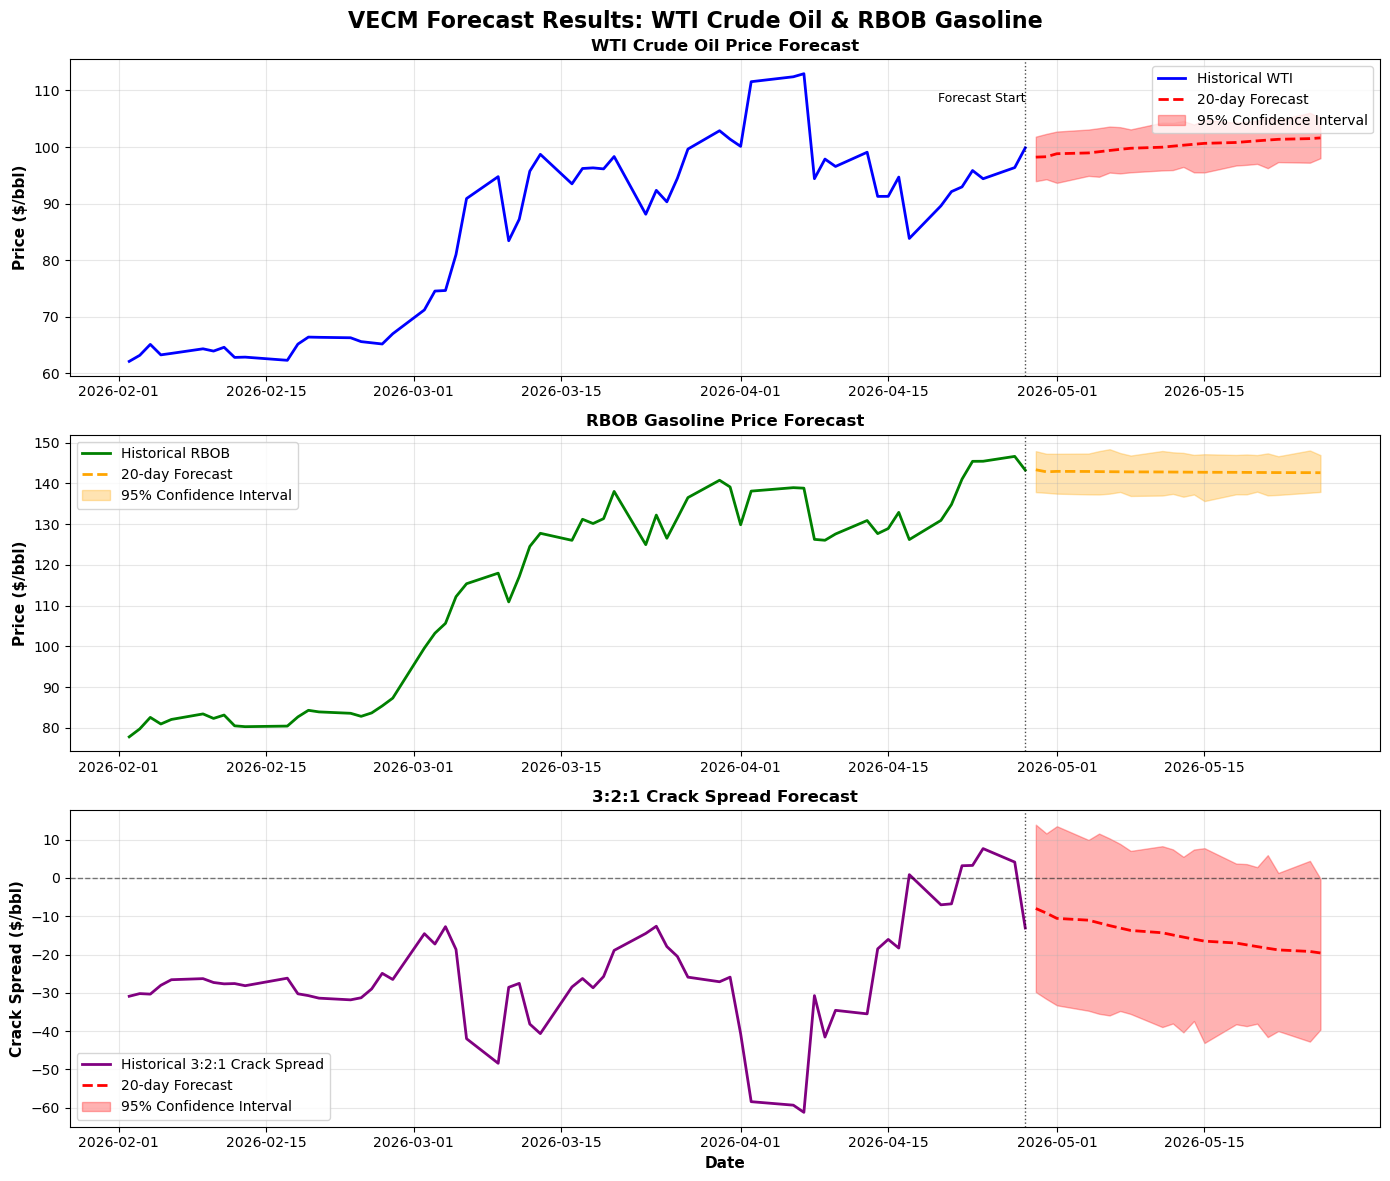

✓ Visualizations generated

MODEL SUMMARY AND DIAGNOSTICS

Full VECM Model Summary:
 Det. terms outside the coint. relation & lagged endog. parameters for equation WTI
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
L1.WTI             -0.3192      0.032    -10.083      0.000      -0.381      -0.257
L1.RBOB_per_bbl     0.1819      0.032      5.643      0.000       0.119       0.245
L2.WTI             -0.1622      0.031     -5.219      0.000      -0.223      -0.101
L2.RBOB_per_bbl     0.0887      0.031      2.821      0.005       0.027       0.150
Det. terms outside the coint. relation & lagged endog. parameters for equation RBOB_per_bbl
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
L1.WTI              0.0444      0.031      1.428      0.153      -0.

In [44]:
# ============================================================================
# PHASE 2: VECM MODEL TRAINING AND FORECASTING
# Goal: Train VECM model and forecast WTI/RBOB prices + crack spread
# ============================================================================
print("=" * 70)
print("PHASE 2: VECM MODEL TRAINING")
print("=" * 70)

# ----------------------------------------------------------------------------
# STEP 1: PREPARE DATA FOR VECM
# ----------------------------------------------------------------------------

print("\n--- STEP 1: DATA PREPARATION ---")

# Use the price data from Phase 1
# Note: price_data already contains aligned WTI and RBOB_per_bbl
vecm_data = price_data[['WTI', 'RBOB_per_bbl']].copy()

print(f"Training data prepared:")
print(f"  Variables: WTI ($/bbl), RBOB Gasoline ($/bbl)")
print(f"  Observations: {len(vecm_data)}")
print(f"  Date range: {vecm_data.index[0].strftime('%Y-%m-%d')} to {vecm_data.index[-1].strftime('%Y-%m-%d')}")
print(f"  Lag order: {optimal_lag_for_johansen}")
print(f"  Cointegration rank: 1")

# ----------------------------------------------------------------------------
# STEP 2: INITIALIZE AND FIT VECM MODEL
# ----------------------------------------------------------------------------

print("\n--- STEP 2: FITTING VECM MODEL ---")

# Initialize VECM
# Parameters:
#   - endog: the data (2 price series)
#   - k_ar_diff: number of lagged differences (from Step 3)
#   - coint_rank: number of cointegrating relationships (from Step 4, should be 1)
#   - deterministic: 'ci' = constant in cointegration space (standard for prices)
vecm_model = VECM(
    endog=vecm_data,
    k_ar_diff=optimal_lag_for_johansen,
    coint_rank=1,
    deterministic='ci'
)

# Fit the model (estimate all parameters)
print("Estimating VECM parameters...")
vecm_fitted = vecm_model.fit()
print("✓ VECM estimation complete")

# ----------------------------------------------------------------------------
# STEP 3: EXTRACT AND DISPLAY MODEL PARAMETERS
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("VECM MODEL PARAMETERS")
print("=" * 70)

# --- COINTEGRATION VECTOR (BETA) ---
# Beta defines the long-run equilibrium relationship
# For 2 variables: beta = [β1, β2] where β1*WTI + β2*RBOB = equilibrium
beta = vecm_fitted.beta
print("\n1. COINTEGRATION VECTOR (β - The 'Leash'):")
print(f"   β₁ (WTI coefficient):  {beta[0, 0]:>10.4f}")
print(f"   β₂ (RBOB coefficient): {beta[1, 0]:>10.4f}")
print(f"\n   Equilibrium relationship:")
print(f"   {beta[0, 0]:.4f} × WTI + {beta[1, 0]:.4f} × RBOB = constant")

# Normalize to interpret as "how many barrels of RBOB = 1 barrel of WTI in equilibrium"
if beta[1, 0] != 0:
    equilibrium_ratio = -beta[0, 0] / beta[1, 0]
    print(f"\n   Long-run equilibrium ratio: 1 bbl WTI ≈ {equilibrium_ratio:.4f} bbl RBOB")

# --- SPEED OF ADJUSTMENT (ALPHA) ---
# Alpha shows how fast prices correct back to equilibrium
# Negative alpha = price decreases when above equilibrium
# Positive alpha = price increases when below equilibrium
alpha = vecm_fitted.alpha
print("\n2. SPEED OF ADJUSTMENT (α - Error Correction):")
print(f"   α₁ (WTI adjustment):  {alpha[0, 0]:>10.4f}")
print(f"   α₂ (RBOB adjustment): {alpha[1, 0]:>10.4f}")
print(f"\n   Interpretation:")

# Calculate half-life: how many days to close half the gap
for i, name in enumerate(['WTI', 'RBOB']):
    adj_speed = alpha[i, 0]
    if adj_speed < 0:
        half_life = -np.log(2) / np.log(1 + adj_speed)
        print(f"   • {name}: Corrects {abs(adj_speed)*100:.2f}% of disequilibrium per day")
        print(f"     Half-life ≈ {half_life:.1f} days to close 50% of gap")
    else:
        print(f"   • {name}: Positive adjustment (unusual, check data)")

# --- SHORT-RUN COEFFICIENTS (GAMMA) ---
# Gamma captures immediate price dynamics (lagged differences)
gamma = vecm_fitted.gamma
print("\n3. SHORT-RUN DYNAMICS (Γ - Lagged Differences):")
print(f"   Shape: {gamma.shape[0]} equations × {gamma.shape[1]} lagged difference terms")
print(f"   (Details omitted for brevity - these capture daily momentum effects)")

# --- ERROR CORRECTION TERM (ECT) ---
# Current deviation from equilibrium
print("\n4. CURRENT ERROR CORRECTION TERM:")
last_prices = vecm_data.iloc[-1].values
ect_current = np.dot(last_prices, beta.flatten())
print(f"   ECT = {ect_current:.4f}")
if ect_current > 0:
    print(f"   → Prices are ABOVE long-run equilibrium")
    print(f"   → Expect downward correction pressure")
else:
    print(f"   → Prices are BELOW long-run equilibrium")
    print(f"   → Expect upward correction pressure")

# ----------------------------------------------------------------------------
# STEP 4: GENERATE FORECASTS
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("GENERATING FORECASTS")
print("=" * 70)

# Forecast horizon (days ahead)
FORECAST_HORIZON = 20  # Adjust this as needed (5-30 days typical)

print(f"\nForecast horizon: {FORECAST_HORIZON} trading days")

# Generate point forecasts
# Returns array of shape (FORECAST_HORIZON, 2) - one column per variable
forecast_values = vecm_fitted.predict(steps=FORECAST_HORIZON)

# Create forecast dates (business days only)
last_date = vecm_data.index[-1]
forecast_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON,
    freq='B'  # Business day frequency
)

# Create forecast DataFrame
forecast_df = pd.DataFrame(
    forecast_values,
    index=forecast_dates,
    columns=['WTI_forecast', 'RBOB_forecast']
)

print("✓ Point forecasts generated")

# --- CALCULATE CONFIDENCE INTERVALS ---
# Using simulation-based approach (bootstrap residuals)
print("\nCalculating 95% confidence intervals...")

# Get fitted values and residuals from the model
fitted_values = vecm_fitted.fittedvalues
residuals = vecm_fitted.resid

# Bootstrap parameters
N_SIMULATIONS = 1000
alpha_level = 0.05  # 95% confidence

# Storage for simulated forecasts
simulated_forecasts = np.zeros((N_SIMULATIONS, FORECAST_HORIZON, 2))

# Bootstrap simulation
np.random.seed(42)  # For reproducibility
for i in range(N_SIMULATIONS):
    # Block bootstrap: randomly select rows from the residual array
    idx = np.random.choice(len(residuals), size=FORECAST_HORIZON, replace=True)
    resampled_residuals = residuals[idx]  # shape (FORECAST_HORIZON, 2)
    
    base_forecast = vecm_fitted.predict(steps=FORECAST_HORIZON)
    simulated_forecasts[i] = base_forecast + resampled_residuals
# Calculate percentiles for confidence intervals
lower_bound = np.percentile(simulated_forecasts, alpha_level/2 * 100, axis=0)
upper_bound = np.percentile(simulated_forecasts, (1 - alpha_level/2) * 100, axis=0)

# Add bounds to forecast DataFrame
forecast_df['WTI_lower'] = lower_bound[:, 0]
forecast_df['WTI_upper'] = upper_bound[:, 0]
forecast_df['RBOB_lower'] = lower_bound[:, 1]
forecast_df['RBOB_upper'] = upper_bound[:, 1]

print("✓ Confidence intervals calculated (95% level)")

# Display first few forecasts
print("\nForecast preview (first 5 days):")
print(forecast_df[['WTI_forecast', 'RBOB_forecast']].head())

# ----------------------------------------------------------------------------
# STEP 5: CALCULATE CRACK SPREAD FORECASTS
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("CRACK SPREAD FORECASTS")
print("=" * 70)

# Calculate 3:2:1 crack spread for forecasts
# Formula: (2 × RBOB revenue) - (3 × WTI cost)
forecast_df['Crack_Spread_forecast'] = (
    2 * forecast_df['RBOB_forecast'] - 3 * forecast_df['WTI_forecast']
)

# Calculate crack spread confidence intervals
forecast_df['Crack_Spread_lower'] = (
    2 * forecast_df['RBOB_lower'] - 3 * forecast_df['WTI_upper']
)
forecast_df['Crack_Spread_upper'] = (
    2 * forecast_df['RBOB_upper'] - 3 * forecast_df['WTI_lower']
)

# Historical crack spread for comparison
historical_crack = (2 * vecm_data['RBOB_per_bbl'] - 3 * vecm_data['WTI'])

# Display spread statistics
current_spread = historical_crack.iloc[-1]
forecast_spread_mean = forecast_df['Crack_Spread_forecast'].mean()

print(f"\nCrack Spread Analysis:")
print(f"  Current (last historical): ${current_spread:.2f}/bbl")
print(f"  Forecast mean ({FORECAST_HORIZON} days): ${forecast_spread_mean:.2f}/bbl")
print(f"  Expected change: ${forecast_spread_mean - current_spread:+.2f}/bbl")

print("\nForecast spread preview (first 5 days):")
print(forecast_df[['Crack_Spread_forecast', 'Crack_Spread_lower', 'Crack_Spread_upper']].head())

# ----------------------------------------------------------------------------
# STEP 6: VISUALIZATION
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("GENERATING VISUALIZATIONS")
print("=" * 70)

# Create comprehensive visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('VECM Forecast Results: WTI Crude Oil & RBOB Gasoline', 
             fontsize=16, fontweight='bold')

# --- SUBPLOT 1: WTI PRICE FORECAST ---
ax1 = axes[0]

# Historical data (last 60 days for context)
historical_window = 60
ax1.plot(vecm_data.index[-historical_window:], 
         vecm_data['WTI'].values[-historical_window:],
         label='Historical WTI', color='blue', linewidth=2)

# Forecast with confidence interval
ax1.plot(forecast_df.index, forecast_df['WTI_forecast'],
         label=f'{FORECAST_HORIZON}-day Forecast', color='red', linewidth=2, linestyle='--')
ax1.fill_between(forecast_df.index,
                  forecast_df['WTI_lower'],
                  forecast_df['WTI_upper'],
                  alpha=0.3, color='red', label='95% Confidence Interval')

# Add vertical line at forecast start
ax1.axvline(x=last_date, color='black', linestyle=':', linewidth=1, alpha=0.7)
ax1.text(last_date, ax1.get_ylim()[1]*0.95, 'Forecast Start', 
         ha='right', va='top', fontsize=9)

ax1.set_ylabel('Price ($/bbl)', fontsize=11, fontweight='bold')
ax1.set_title('WTI Crude Oil Price Forecast', fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# --- SUBPLOT 2: RBOB GASOLINE PRICE FORECAST ---
ax2 = axes[1]

# Historical data
ax2.plot(vecm_data.index[-historical_window:],
         vecm_data['RBOB_per_bbl'].values[-historical_window:],
         label='Historical RBOB', color='green', linewidth=2)

# Forecast with confidence interval
ax2.plot(forecast_df.index, forecast_df['RBOB_forecast'],
         label=f'{FORECAST_HORIZON}-day Forecast', color='orange', linewidth=2, linestyle='--')
ax2.fill_between(forecast_df.index,
                  forecast_df['RBOB_lower'],
                  forecast_df['RBOB_upper'],
                  alpha=0.3, color='orange', label='95% Confidence Interval')

# Add vertical line at forecast start
ax2.axvline(x=last_date, color='black', linestyle=':', linewidth=1, alpha=0.7)

ax2.set_ylabel('Price ($/bbl)', fontsize=11, fontweight='bold')
ax2.set_title('RBOB Gasoline Price Forecast', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# --- SUBPLOT 3: CRACK SPREAD FORECAST ---
ax3 = axes[2]

# Historical crack spread
ax3.plot(vecm_data.index[-historical_window:],
         historical_crack.values[-historical_window:],
         label='Historical 3:2:1 Crack Spread', color='purple', linewidth=2)

# Forecast crack spread with confidence interval
ax3.plot(forecast_df.index, forecast_df['Crack_Spread_forecast'],
         label=f'{FORECAST_HORIZON}-day Forecast', color='red', linewidth=2, linestyle='--')
ax3.fill_between(forecast_df.index,
                  forecast_df['Crack_Spread_lower'],
                  forecast_df['Crack_Spread_upper'],
                  alpha=0.3, color='red', label='95% Confidence Interval')

# Add zero line (break-even)
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add vertical line at forecast start
ax3.axvline(x=last_date, color='black', linestyle=':', linewidth=1, alpha=0.7)

ax3.set_xlabel('Date', fontsize=11, fontweight='bold')
ax3.set_ylabel('Crack Spread ($/bbl)', fontsize=11, fontweight='bold')
ax3.set_title('3:2:1 Crack Spread Forecast', fontsize=12, fontweight='bold')
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

# Adjust layout and display
plt.tight_layout()
plt.show()

print("✓ Visualizations generated")

# ----------------------------------------------------------------------------
# STEP 7: MODEL DIAGNOSTICS AND SUMMARY
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL SUMMARY AND DIAGNOSTICS")
print("=" * 70)

# Display full model summary
print("\nFull VECM Model Summary:")
print(vecm_fitted.summary())

# Key statistics
print("\n" + "=" * 70)
print("KEY TAKEAWAYS")
print("=" * 70)

print(f"\n1. Model Structure:")
print(f"   • Variables: WTI Crude Oil, RBOB Gasoline")
print(f"   • Lag order: {optimal_lag_for_johansen}")
print(f"   • Cointegration rank: 1 (one long-run relationship)")
print(f"   • Sample: {vecm_data.index[0].strftime('%Y-%m-%d')} to {vecm_data.index[-1].strftime('%Y-%m-%d')}")

print(f"\n2. Long-Run Equilibrium:")
print(f"   • Equilibrium ratio: 1 bbl WTI ≈ {equilibrium_ratio:.4f} bbl RBOB")
print(f"   • Current ECT: {ect_current:.4f} ({'above' if ect_current > 0 else 'below'} equilibrium)")

print(f"\n3. Error Correction:")
print(f"   • WTI adjusts at {abs(alpha[0, 0])*100:.2f}% per day")
print(f"   • RBOB adjusts at {abs(alpha[1, 0])*100:.2f}% per day")

print(f"\n4. Forecast Summary:")
print(f"   • Horizon: {FORECAST_HORIZON} trading days")
print(f"   • WTI: ${vecm_data['WTI'].iloc[-1]:.2f} → ${forecast_df['WTI_forecast'].iloc[-1]:.2f}")
print(f"   • RBOB: ${vecm_data['RBOB_per_bbl'].iloc[-1]:.2f} → ${forecast_df['RBOB_forecast'].iloc[-1]:.2f}")
print(f"   • Crack Spread: ${current_spread:.2f} → ${forecast_df['Crack_Spread_forecast'].iloc[-1]:.2f}")

print("\n" + "=" * 70)
print("✓ VECM ANALYSIS COMPLETE")
print("=" * 70)